## Understanding the H&M Customer Base

H&M Group is a family of brands and businesses with 53 online markets and approximately 4,850 stores.
This project uses H&M retail data to see how customer age and product styles affect what people buy.

#### Primary Objectives
The goal of this project is to answer three high-impact business questions:

***Demographic Spending:*** How does purchasing power vary across different age groups, and which generation represents the "High Value" customer for H&M?

***Product & Color:*** What are the top-performing product colors, and do color preferences shift as customers age?

***Shopping Habits:*** On which days of the week do customers shop the most?

#### The project includes the following steps:
1. Data Loading and Sampling
2. Initial Inspection of Data
3. Table Merging
4. Data Cleaning and Feature Engineering
5. Spending By Age Group (Visual 1)
6. Frequency Analysis: Products, Colors, and Bundles
7. Top 5 Color Preferences by Age Group (Visual 2)
8. Purchases By Day of Week (Visual 3)
9. Conclusion

data source: https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data

In [1]:
# Global imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import time
start_time = time.time()


### Datasets description
**articles.csv**  - detailed metadata for each article_id available for purchase

**customers.csv** - metadata for each customer_id in dataset

**transactions_train.csv** - the training data, consisting of the purchases each customer for each date, 
as well as additional information. Duplicate rows correspond to multiple purchases of the same item.

Due to the data size limit requirements and chronological sorting of the original transactions_train.csv dataset, the 100,000-row sample captures a specific shopping window in September.

### 1. Data Loading and Sampling

In [2]:
# load data and get a sample data, nrows=100000
trans = pd.read_csv('transactions_train.csv', nrows=100000) 
articles = pd.read_csv('articles.csv')
customers = pd.read_csv('customers.csv')

In [3]:
# preprocess the data to meet the size limit requirements
# create a random sample of 10,000 customers
sample_customers = customers.sample(n=10000, random_state=42)

In [4]:
# Filter transactions to only include those 5,000 customers
sample_trans = trans[trans['customer_id'].isin(sample_customers['customer_id'])]

In [5]:
#convert samples to .csv datasets
sample_trans.to_csv('trans_df.csv', index=False)
sample_customers.to_csv('customers_df.csv', index=False)
articles.to_csv('articles_df.csv', index=False)

In [6]:
#read files and define datasets
df_articles = pd.read_csv('articles_df.csv', usecols=['article_id', 'prod_name', 'product_type_name', 
    'product_group_name', 'colour_group_name', 'index_group_name'])
df_customers = pd.read_csv('customers_df.csv')
df_trans = pd.read_csv('trans_df.csv')

### 2. Initial Inspection of Data

In [7]:
#datasets info
df_articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   article_id          105542 non-null  int64 
 1   prod_name           105542 non-null  object
 2   product_type_name   105542 non-null  object
 3   product_group_name  105542 non-null  object
 4   colour_group_name   105542 non-null  object
 5   index_group_name    105542 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.8+ MB


In [8]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   FN                      3455 non-null   float64
 2   Active                  3384 non-null   float64
 3   club_member_status      9963 non-null   object 
 4   fashion_news_frequency  9887 non-null   object 
 5   age                     9894 non-null   float64
 6   postal_code             10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [9]:
df_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   t_dat             649 non-null    object 
 1   customer_id       649 non-null    object 
 2   article_id        649 non-null    int64  
 3   price             649 non-null    float64
 4   sales_channel_id  649 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 25.5+ KB


### 3. Table Merging

Join the transactions table with the articles and customers tables to create a master dataframe.

In [10]:
# Merge transactions with articles
df = df_trans.merge(df_articles, on='article_id', how='left')
df.head()


,t_dat,customer_id,article_id,price,sales_channel_id,prod_name,product_type_name,product_group_name,colour_group_name,index_group_name
0,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,626168001,0.027102,2,Tiffany maxi,Skirt,Garment Lower body,Light Yellow,Divided
1,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,583976001,0.025407,2,Alba dress,Dress,Garment Full body,Black,Divided
2,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,558428001,0.035576,2,Peggy Biker PU,Leggings/Tights,Garment Lower body,Black,Divided
3,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,636420001,0.040661,2,Salsa frill skirt,Skirt,Garment Lower body,Dark Blue,Ladieswear
4,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,587229001,0.015237,2,Lazer Razer Highwaist,Swimwear bottom,Swimwear,Black,Ladieswear


In [11]:
#Merge df with customers
master_df = df.merge(df_customers[['customer_id', 'age', 'club_member_status']], on='customer_id', how='left')
master_df.head()


,t_dat,customer_id,article_id,price,sales_channel_id,prod_name,product_type_name,product_group_name,colour_group_name,index_group_name,age,club_member_status
0,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,626168001,0.027102,2,Tiffany maxi,Skirt,Garment Lower body,Light Yellow,Divided,30.0,ACTIVE
1,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,583976001,0.025407,2,Alba dress,Dress,Garment Full body,Black,Divided,30.0,ACTIVE
2,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,558428001,0.035576,2,Peggy Biker PU,Leggings/Tights,Garment Lower body,Black,Divided,30.0,ACTIVE
3,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,636420001,0.040661,2,Salsa frill skirt,Skirt,Garment Lower body,Dark Blue,Ladieswear,30.0,ACTIVE
4,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,587229001,0.015237,2,Lazer Razer Highwaist,Swimwear bottom,Swimwear,Black,Ladieswear,30.0,ACTIVE


In [12]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 649 entries, 0 to 648
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   t_dat               649 non-null    object 
 1   customer_id         649 non-null    object 
 2   article_id          649 non-null    int64  
 3   price               649 non-null    float64
 4   sales_channel_id    649 non-null    int64  
 5   prod_name           649 non-null    object 
 6   product_type_name   649 non-null    object 
 7   product_group_name  649 non-null    object 
 8   colour_group_name   649 non-null    object 
 9   index_group_name    649 non-null    object 
 10  age                 647 non-null    float64
 11  club_member_status  644 non-null    object 
dtypes: float64(2), int64(2), object(8)
memory usage: 65.9+ KB


In [13]:
#Check for na values
master_df.isna().sum()

t_dat                 0
customer_id           0
article_id            0
price                 0
sales_channel_id      0
prod_name             0
product_type_name     0
product_group_name    0
colour_group_name     0
index_group_name      0
age                   2
club_member_status    5
dtype: int64

### 4. Data Cleaning and Feature Engineering

In [14]:
#Calculate median age to fill missing age
mean_age = master_df['age'].median()
master_df['age'] = master_df['age'].fillna(mean_age)
master_df.isna().sum()

t_dat                 0
customer_id           0
article_id            0
price                 0
sales_channel_id      0
prod_name             0
product_type_name     0
product_group_name    0
colour_group_name     0
index_group_name      0
age                   0
club_member_status    5
dtype: int64

In [15]:
#Convert t_dat to datetime and extract month, day
master_df['t_dat'] = pd.to_datetime(master_df['t_dat'])
master_df['month'] = master_df['t_dat'].dt.month_name()
master_df['day'] = master_df['t_dat'].dt.day_name()
master_df.head(1)

,t_dat,customer_id,article_id,price,sales_channel_id,prod_name,product_type_name,product_group_name,colour_group_name,index_group_name,age,club_member_status,month,day
0,2018-09-20,01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...,626168001,0.027102,2,Tiffany maxi,Skirt,Garment Lower body,Light Yellow,Divided,30.0,ACTIVE,September,Thursday


In [16]:
#define custom age bins
bins = [0, 19, 30, 60, 100]
labels = ['Youth','Young Adult', 'Adult', 'Senior']

In [17]:
#Create age_groups column using age bins and labels
master_df['age_groups'] = pd.cut(master_df['age'], bins=bins, labels=labels)
master_df['age_groups'].values

['Young Adult', 'Young Adult', 'Young Adult', 'Young Adult', 'Young Adult', ..., 'Young Adult', 'Senior', 'Senior', 'Senior', 'Senior']
Length: 649
Categories (4, object): ['Youth' < 'Young Adult' < 'Adult' < 'Senior']

In [18]:
#The price values is a normalized float.The documentation doesn't specify a currency,
#so I will treat it as a relative value or a percentage of a maximum price for anonymity.
master_df['relative_price'] = master_df['price'] * 100

### 5. Spending By Age Group (Visual 1)

In [19]:
#Create a plot that shows the proportion of total revenue contributed by each age group
#Calculate total revenue
total_revenue = master_df['relative_price'].sum()

In [20]:
#Group age groups and sum their spending and calculate the proportion of spending per age group
group_spending = (master_df.groupby('age_groups')['relative_price'].sum() / total_revenue) * 100

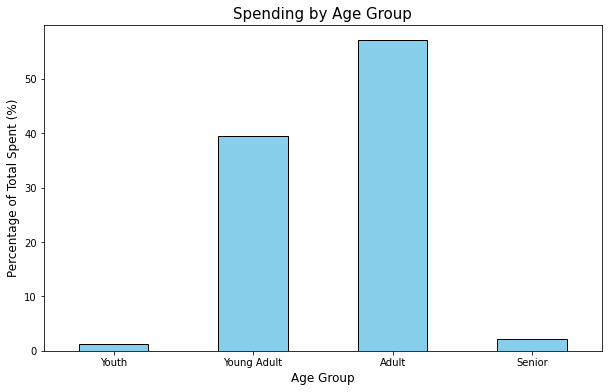

In [21]:
#Create a plot
plt.figure(figsize=(10, 6))
ax = group_spending.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Spending by Age Group', fontsize=15)
plt.ylabel('Percentage of Total Spent (%)', fontsize=12)
plt.xlabel('Age Group', fontsize=12)
plt.xticks(rotation=0) # Keeps labels horizontal and easy to read

plt.show()

### 6. Frequency Analysis: Products, Colors, and Bundles

In [22]:
#Identify the top five most purchased items
top_five_products = master_df['product_type_name'].value_counts().head(5)
print(top_five_products)

Sweater     115
Trousers    103
Dress        56
T-shirt      52
Top          28
Name: product_type_name, dtype: int64


In [23]:
#Group by customer and date to create product groups
product_groups = master_df.groupby(['customer_id','t_dat'])['product_type_name'].apply(list)

In [24]:
#Identify items that are frequently bought together
pairs = []

for product in product_groups:
    if len(product) > 1:
        pairs.extend(list(itertools.combinations(sorted(product), 2)))
        
#Convert to Series and count occurrences
top_pairs = pd.Series(pairs).value_counts().head(5)
print(top_pairs)
        
    

(Dress, Dress)          272
(Sweater, Sweater)       94
(Trousers, Trousers)     81
(Shorts, Vest top)       80
(T-shirt, Trousers)      64
dtype: int64


In [25]:
#Identify top five colors that are frequently purchased
top_colors = master_df['colour_group_name'].value_counts().head(5)
print(top_colors)

Black        218
Dark Blue     92
White         70
Grey          34
Blue          27
Name: colour_group_name, dtype: int64


In [26]:
# create a subset df that includes to 5 colors
df_colors = master_df[master_df['colour_group_name'].isin(top_colors.index)]
print(df_colors.head(5))

       t_dat                                        customer_id  article_id  \
1 2018-09-20  01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...   583976001   
2 2018-09-20  01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...   558428001   
3 2018-09-20  01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...   636420001   
4 2018-09-20  01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...   587229001   
5 2018-09-20  01fbe7968ede05b116c4d878d47ed4fd33db355c4b3311...   650578001   

      price  sales_channel_id              prod_name product_type_name  \
1  0.025407                 2             Alba dress             Dress   
2  0.035576                 2         Peggy Biker PU   Leggings/Tights   
3  0.040661                 2      Salsa frill skirt             Skirt   
4  0.015237                 2  Lazer Razer Highwaist   Swimwear bottom   
5  0.006763                 2              Brook top               Top   

   product_group_name colour_group_name index_group_name   age  \
1   Garment Fu

### 7. Top 5 Color Preferences by Age Group (Visual 2)

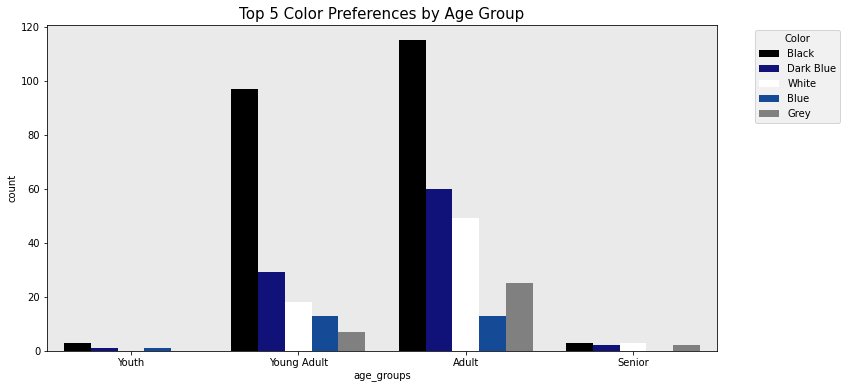

In [27]:
# create Grouped Bar Chart
colors = {
    'Black': '#000000',
    'White': '#FFFFFF',
    'Grey': '#808080', 
    'Dark Blue': '#00008B',
    'Blue': '#0047AB'    
}
    
plt.figure(figsize=(12, 6))
sns.countplot(data=df_colors, x='age_groups', hue='colour_group_name', palette=colors)

plt.title('Top 5 Color Preferences by Age Group', fontsize=15)
legend = plt.legend(title='Color', bbox_to_anchor=(1.05, 1), loc='upper left')

#access legend frame to change background
frame = legend.get_frame()
frame.set_facecolor('#EEEEEE')

#set plot background
plt.gca().set_facecolor('#EAEAEA')
plt.show()

### 8. Purchases By Day of Week (Visual 3)

In [28]:
#Identify days when people shop the most and visualize the results
master_df[['month','day']].value_counts()

month      day     
September  Thursday    398
           Friday      238
           Saturday     13
dtype: int64

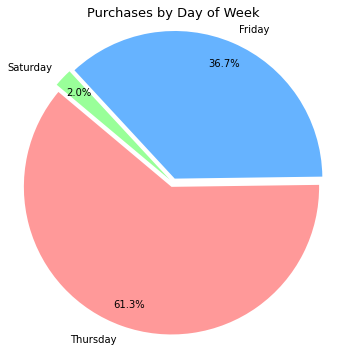

In [29]:
day_groups = master_df['day'].value_counts()
plt.figure(figsize=(5, 5))
colors = ['#ff9999','#66b3ff','#99ff99'] 

# Create the pie chart
plt.pie(day_groups, labels=day_groups.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, pctdistance=0.85, 
        explode=[0.03]*len(day_groups)) # Adds small gaps between slices

plt.title('Purchases by Day of Week', fontsize=13)
plt.axis('equal') 
plt.tight_layout()
plt.show()

### 9. Conclusion

In this project I grouped customers by age to find the most profitable demographic; identified the top 5 colors and products and checked if different ages prefer different colors; and analyzed which days of the week have the most sales.

The analysis revealed that the customers aged 30-60 representing the Adult group spend the most; the most frequent item pairings were duplicates of the same category (e.g., two dresses or two sweaters) primarily in black and dark blue colors. This suggests that customers in this sample tend to 'stock up' on specific garment types. 
I also identified logical outfit pairings, such as t-shirts with trousers and shorts with vest tops.
Because I had to sample the data to fit data size limits, these results represent a snapshot and might differ from the full customer set.

Based on the finding of the project, H&M could focus its marketing and rewards on adults aged 30–60, as they are the highest spenders. To take advantage of the "stocking up" trend, H&M could offer multi-buy deals (like BOGO) on wardrobe staples, especially in popular colors like black and dark blue. Finally, the company could use the identified peak shopping days to better plan inventory restocks and store staffing.

In [30]:
end_time = time.time()
total_seconds = end_time - start_time
print(f"Total Execution Time: {total_seconds / 60:.2f} minutes ({total_seconds:.2f} seconds)")

Total Execution Time: 0.13 minutes (7.75 seconds)
